# Step 00 — Data provenance and objective reproducibility audit

This notebook reruns the **current step 00 contract** with two explicit goals:

1. keep a hard separation between the **legacy historical Optuna DB/CSV assets** and the **new ATF dataset**;
2. make the remaining unresolved historical-control provenance explicit rather than trying to over-interpret it.

## Reuse from `astro_atf_analysis_improved_sectioned.ipynb`

This notebook does **not** reuse the ATF signal preprocessing or feature extraction logic from the reference notebook.  
It only uses the same ATF filename contract (`DH`/`VH`, `CONTROL`/`MFA`/`MFA_BA`) so that step 00 and step 02 stay consistent about what the ATF files are.

## Important interpretation change

`CONTROL_TRACES_old.csv` has been removed and is not used here.  
That cleanup is correct, but it does **not** validate the historical control DB objectives: with the documented `CONTROL_TRACES.csv` source, the historical control fits remain unresolved.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path(os.environ.get("ASTROMODEL_PROJECT_ROOT", Path.cwd())).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.provenance import run_step00_provenance

pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", 200)

PROJECT_ROOT

PosixPath('/mnt/data/astromodel_proving_updated')

In [2]:
results = run_step00_provenance(PROJECT_ROOT)

db_summary = results["db_study_summary"]
trace_summary = results["trace_source_summary"]
provenance = results["control_trace_verification"]
atf_inventory = results["atf_region_condition_inventory"]
atf_counts = results["atf_region_condition_counts"]
data_contract = results["data_source_contract"]

print("written outputs:", sorted((PROJECT_ROOT / "outputs" / "provenance").glob("*.csv")))
print("db rows:", len(db_summary), "trace rows:", len(trace_summary), "ATF rows:", len(atf_inventory))

written outputs: [PosixPath('/mnt/data/astromodel_proving_updated/outputs/provenance/atf_region_condition_counts.csv'), PosixPath('/mnt/data/astromodel_proving_updated/outputs/provenance/atf_region_condition_inventory.csv'), PosixPath('/mnt/data/astromodel_proving_updated/outputs/provenance/control_trace_verification.csv'), PosixPath('/mnt/data/astromodel_proving_updated/outputs/provenance/data_source_contract.csv'), PosixPath('/mnt/data/astromodel_proving_updated/outputs/provenance/db_study_summary.csv'), PosixPath('/mnt/data/astromodel_proving_updated/outputs/provenance/trace_source_summary.csv')]
db rows: 18 trace rows: 3 ATF rows: 37


## Dataset contract: legacy historical assets versus new ATF traces

In [3]:
display(data_contract)

,dataset_kind,path_pattern,role,used_in_steps,reviewer_priority,notes
0,legacy_optuna_db,data/1_Initial_xp_fit/*.db,Historical single-current fit archive.,"00,01",legacy_context_only,"Best used for provenance audit, structural con..."
1,legacy_optuna_trace_csv,data/1_Initial_xp_fit/*_TRACES.csv,Historical target traces used when the origina...,"00,01",legacy_context_only,CONTROL_TRACES_old.csv was removed and must no...
2,legacy_threshold_example_csv,data/threshold_for_good_enough_fits(TO BE RECO...,Legacy threshold example kept only for provena...,00,legacy_context_only,Thresholds must be rebuilt from ATF data in st...
3,new_atf_trace,data/2_K+ Pumps Data/*.atf,New reviewer-facing experimental traces for re...,"00,02+",primary_reviewer_dataset,DH/VH region and CONTROL/MFA/MFA_BA condition ...


## Historical DB study inventory

,db_name,study_name,condition,current_na,target_mean_mode,objective_loss_type,n_target_points,n_trials,n_complete,best_trial_number,best_objective
0,BARIUM_50nA.db,BARIUM_50nA_centered_L2_20000t_20240930_133313,BARIUM,50,centered,L2,20000,11907,11906,0,3450.286230
1,BARIUM_75nA.db,BARIUM_75nA_centered_L2_20000t_20240930_133312,BARIUM,75,centered,L2,20000,11925,11924,0,5848.293742
2,BARIUM_100nA.db,BARIUM_100nA_centered_L2_20000t_20240930_133313,BARIUM,100,centered,L2,20000,11903,11902,0,7963.653221
3,BARIUM_125nA.db,BARIUM_125nA_centered_L2_20000t_20240930_133313,BARIUM,125,centered,L2,20000,11914,11913,0,13492.704819
4,BARIUM_150nA.db,BARIUM_150nA_centered_L2_20000t_20240930_133313,BARIUM,150,centered,L2,20000,11924,11923,4311,23509.572968
5,BARIUM_175nA.db,BARIUM_175nA_centered_L2_20000t_20240930_133313,BARIUM,175,centered,L2,20000,11942,11941,0,28903.238239
6,CONTROL_50nA.db,CONTROL_50nA_centered_L2_2500t,CONTROL,50,centered,L2,2500,2500,2500,2067,21.502226
7,CONTROL_75nA.db,CONTROL_75nA_centered_L2_2500t,CONTROL,75,centered,L2,2500,2500,2500,2425,30.054498
8,CONTROL_100nA.db,CONTROL_100nA_centered_L2_2500t,CONTROL,100,centered,L2,2500,2500,2500,1943,38.365141
9,CONTROL_125nA.db,CONTROL_125nA_centered_L2_2500t,CONTROL,125,centered,L2,2500,2500,2500,1929,102.645495


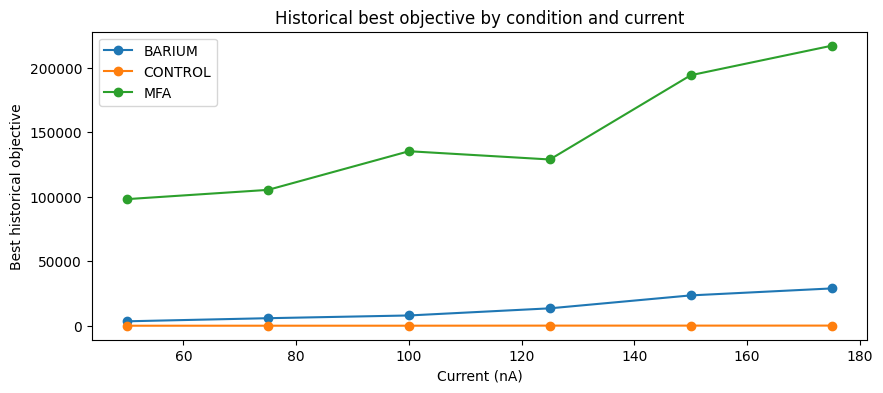

In [4]:
display(db_summary)

fig, ax = plt.subplots(figsize=(10, 4))
for condition, group in db_summary.groupby("condition"):
    ax.plot(group["current_na"], group["best_objective"], marker="o", label=condition)
ax.set_xlabel("Current (nA)")
ax.set_ylabel("Best historical objective")
ax.set_title("Historical best objective by condition and current")
ax.legend()
plt.show()

## Historical trace sources used by the legacy objectives

In [5]:
display(trace_summary)

,trace_source,condition,rows,n_columns,time_start_ms,time_end_ms,dt_ms,uses_header,file_size_bytes,dataset_kind
0,BARIUM_TRACES.csv,BARIUM,364969,7,0.0,72993.6,0.2,False,24883254,legacy_optuna_trace_csv
1,CONTROL_TRACES.csv,CONTROL,50031,7,0.0,50030.0,1.0,False,3100699,legacy_optuna_trace_csv
2,MFA_TRACES.csv,MFA,364969,7,0.0,72993.6,0.2,False,25187251,legacy_optuna_trace_csv


## New ATF inventory and region × condition counts

In [6]:
display(atf_counts)
display(atf_inventory)

,region,condition,n_cells,expected_n_cells,matches_expected,small_stratum
0,DH,CONTROL,7,7,True,False
1,DH,MFA,6,6,True,False
2,DH,MFA_BA,6,6,True,False
3,VH,CONTROL,4,4,True,True
4,VH,MFA,7,7,True,False
5,VH,MFA_BA,7,7,True,False


,file_id,region,condition,source_path,dataset_kind
0,1_DH_1_CONTROL,DH,CONTROL,/mnt/data/astromodel_proving_updated/data/2_K+...,new_atf_trace
1,1_DH_2_CONTROL,DH,CONTROL,/mnt/data/astromodel_proving_updated/data/2_K+...,new_atf_trace
2,2_DH_1_CONTROL,DH,CONTROL,/mnt/data/astromodel_proving_updated/data/2_K+...,new_atf_trace
3,3_DH_1_CONTROL,DH,CONTROL,/mnt/data/astromodel_proving_updated/data/2_K+...,new_atf_trace
4,3_DH_2_CONTROL,DH,CONTROL,/mnt/data/astromodel_proving_updated/data/2_K+...,new_atf_trace
5,DH_1_CONTROL,DH,CONTROL,/mnt/data/astromodel_proving_updated/data/2_K+...,new_atf_trace
6,DH_2_CONTROL,DH,CONTROL,/mnt/data/astromodel_proving_updated/data/2_K+...,new_atf_trace
7,1_VH_1_CONTROL,VH,CONTROL,/mnt/data/astromodel_proving_updated/data/2_K+...,new_atf_trace
8,1_VH_2_CONTROL,VH,CONTROL,/mnt/data/astromodel_proving_updated/data/2_K+...,new_atf_trace
9,2_VH_1_CONTROL,VH,CONTROL,/mnt/data/astromodel_proving_updated/data/2_K+...,new_atf_trace


## Historical objective reproducibility against documented trace sources

In [7]:
summary = (
    provenance.groupby(["condition", "chosen_status"], dropna=False)
    .size()
    .rename("n_dbs")
    .reset_index()
    .sort_values(["condition", "chosen_status"])
    .reset_index(drop=True)
)
display(summary)
display(provenance)

,condition,chosen_status,n_dbs
0,BARIUM,verified,6
1,CONTROL,unresolved,6
2,MFA,unresolved,1
3,MFA,verified,5


,db_name,study_name,condition,current_na,trace_source,target_mean_mode,objective_loss_type,n_target_points,best_trial_number,stored_objective,recomputed_objective,relative_objective_error,status,chosen_trace_source,chosen_relative_objective_error,chosen_status,trace_dataset_kind
0,BARIUM_50nA.db,BARIUM_50nA_centered_L2_20000t_20240930_133313,BARIUM,50,BARIUM_TRACES.csv,centered,L2,20000,0,3450.286230,3450.068017,0.000063,verified,BARIUM_TRACES.csv,0.000063,verified,legacy_optuna_trace_csv
1,BARIUM_75nA.db,BARIUM_75nA_centered_L2_20000t_20240930_133312,BARIUM,75,BARIUM_TRACES.csv,centered,L2,20000,0,5848.293742,5848.496261,0.000035,verified,BARIUM_TRACES.csv,0.000035,verified,legacy_optuna_trace_csv
2,BARIUM_100nA.db,BARIUM_100nA_centered_L2_20000t_20240930_133313,BARIUM,100,BARIUM_TRACES.csv,centered,L2,20000,0,7963.653221,7963.606994,0.000006,verified,BARIUM_TRACES.csv,0.000006,verified,legacy_optuna_trace_csv
3,BARIUM_125nA.db,BARIUM_125nA_centered_L2_20000t_20240930_133313,BARIUM,125,BARIUM_TRACES.csv,centered,L2,20000,0,13492.704819,13492.676885,0.000002,verified,BARIUM_TRACES.csv,0.000002,verified,legacy_optuna_trace_csv
4,BARIUM_150nA.db,BARIUM_150nA_centered_L2_20000t_20240930_133313,BARIUM,150,BARIUM_TRACES.csv,centered,L2,20000,4311,23509.572968,23509.789390,0.000009,verified,BARIUM_TRACES.csv,0.000009,verified,legacy_optuna_trace_csv
5,BARIUM_175nA.db,BARIUM_175nA_centered_L2_20000t_20240930_133313,BARIUM,175,BARIUM_TRACES.csv,centered,L2,20000,0,28903.238239,28903.329357,0.000003,verified,BARIUM_TRACES.csv,0.000003,verified,legacy_optuna_trace_csv
6,CONTROL_50nA.db,CONTROL_50nA_centered_L2_2500t,CONTROL,50,CONTROL_TRACES.csv,centered,L2,2500,2067,21.502226,4897.230255,226.754575,unresolved,CONTROL_TRACES.csv,226.754575,unresolved,legacy_optuna_trace_csv
7,CONTROL_75nA.db,CONTROL_75nA_centered_L2_2500t,CONTROL,75,CONTROL_TRACES.csv,centered,L2,2500,2425,30.054498,7330.351969,242.901992,unresolved,CONTROL_TRACES.csv,242.901992,unresolved,legacy_optuna_trace_csv
8,CONTROL_100nA.db,CONTROL_100nA_centered_L2_2500t,CONTROL,100,CONTROL_TRACES.csv,centered,L2,2500,1943,38.365141,8823.381495,228.984338,unresolved,CONTROL_TRACES.csv,228.984338,unresolved,legacy_optuna_trace_csv
9,CONTROL_125nA.db,CONTROL_125nA_centered_L2_2500t,CONTROL,125,CONTROL_TRACES.csv,centered,L2,2500,1929,102.645495,26230.452977,254.544123,unresolved,CONTROL_TRACES.csv,254.544123,unresolved,legacy_optuna_trace_csv


## Consequence for later steps

The step 00 result is now cleaner and more honest:

- **BARIUM** historical objectives remain reproducible from `BARIUM_TRACES.csv`.
- **MFA** is mostly reproducible, with `MFA_150nA` still unresolved.
- **CONTROL** remains unresolved under the documented `CONTROL_TRACES.csv` source.

That means step 01 should be interpreted as a **legacy diagnostic step**, while step 02 remains the main immediate reviewer-facing gain because it rebuilds thresholds directly from the 37 ATF files.